Training Test

{'encoder_features': {'backbone': 'cnn', 'backbone_cfg': {'backbone': 'efficientnet_v2_s', 'hidden_dim': 64, 'dropout_rate': 0.0, 'output_dim': 2}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/strong_lenses/models/encoder_features'}, 'encoder_labels': {'backbone': 'mlp', 'backbone_cfg': {'input_dim': 2, 'layer_widths': [8, 8, 8], 'output_dim': 2, 'activation_func': 'silu', 'activate_final': False}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/strong_lenses/encoder_labels'}, 'data': {'path': '/home/noedia/scratch/crl/experiments/strong_lenses/data', 'data_split': None}, 'trainer': {'epochs': 10, 'optimizer': 'adam', 'batch_size': 512, 'lr': '1e-3', 'seed': 42, 'device': 'auto', 'normalize': True, 'transform': None, 'loss_criterion': 5.601, 'delta_criterion': '5e-4'}}
training set size:  (12000, 3)
val set size:  (3000, 3)
Running on device cuda
10


Train Loss = 5.704 | Val Loss = 5.697| Epoch train loss = 131.142 | :  90%|█████████ | 9/10 [08:51<00:54, 54.01s/it]

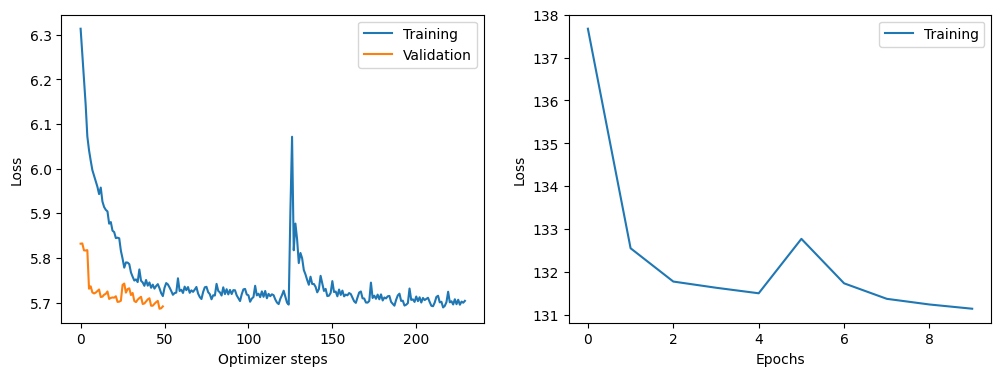

Train Loss = 5.704 | Val Loss = 5.697| Epoch train loss = 131.142 | : 100%|██████████| 10/10 [09:01<00:00, 54.14s/it]


Saving encoder features model
Saving encoder labels model


In [1]:
from astro_peek.utils import load_yaml
from astro_peek.trainer import training
from astro_peek.nets.architectures.cnn import CNN
cfg_dir = "../../astro_peek/configs/strong_lenses.yaml"
cfg = load_yaml(cfg_dir)
cfg["trainer"]["epochs"] = 10
print(cfg)
encoder_x_a, encoder_y_a, loss_a, epoch_loss_a, val_loss_a = training(cfg)

In [ ]:
cfg = load_yaml(cfg_dir)
cfg["trainer"]["epochs"] = 10
cfg["trainer"]["seed"] = 44
print(cfg)
encoder_x_b, encoder_y_b, loss_b, epoch_loss_b, val_loss_b = training(cfg)

{'encoder_features': {'backbone': 'cnn', 'backbone_cfg': {'backbone': 'efficientnet_v2_s', 'hidden_dim': 64, 'dropout_rate': 0.0, 'output_dim': 2}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/strong_lenses/models/encoder_features'}, 'encoder_labels': {'backbone': 'mlp', 'backbone_cfg': {'input_dim': 2, 'layer_widths': [8, 8, 8], 'output_dim': 2, 'activation_func': 'silu', 'activate_final': False}, 'save_dir': '/home/noedia/links/scratch/crl/experiments/strong_lenses/encoder_labels'}, 'data': {'path': '/home/noedia/scratch/crl/experiments/strong_lenses/data', 'data_split': None}, 'trainer': {'epochs': 10, 'optimizer': 'adam', 'batch_size': 512, 'lr': '1e-3', 'seed': 44, 'device': 'auto', 'normalize': True, 'transform': None, 'loss_criterion': 5.601, 'delta_criterion': '5e-4'}}
training set size:  (12000, 3)
val set size:  (3000, 3)
Running on device cuda
10


Train Loss = 5.824 | Val Loss = 0.000| Epoch train loss = 137.022 | :   0%|          | 0/10 [00:44<?, ?it/s]

In [ ]:
cfg = load_yaml(cfg_dir)
cfg["trainer"]["epochs"] = 10
cfg["trainer"]["seed"] = 40
print(cfg)
encoder_x_c, encoder_y_c, loss_c, epoch_loss_c, val_loss_b = training(cfg)

In [ ]:
print(epoch_loss_a[-1], epoch_loss_b[-1], epoch_loss_c[-1])

Checking if the encoded image and encoded labels are separated in latent space or not

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
def sample_prior(prior, size):
    return prior(size)

# prior_params_config = {
#         "einstein_radius": {"low": 0.8, "high": 1.5}, 
#         "phi": {"low": -np.pi/2, "high": np.pi/4}
#     }


# radius_prior = prior_params_config["einstein_radius"]
# phi_prior = prior_params_config["phi"]
# prior_sampler_radius = lambda size: np.random.uniform(radius_prior["low"], radius_prior["high"], size = size)
# prior_sampler_phi = lambda size: np.random.uniform(phi_prior["low"], phi_prior["high"], size = size)

prior_radius_a = lambda size: np.random.normal(loc = 0.9, scale = 0.01, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 1.2, scale = 0.01, size = size)

prior_phi_a = lambda size: np.random.normal(loc = -np.pi/3, scale = 0.05, size = size)
prior_phi_b = lambda size: np.random.normal(loc = 0, scale = 0.05, size = size)


fig, axs = plt.subplots(1, 2, figsize = (12, 4))
ax = axs[0]
samples_a = sample_prior(prior_radius_a, size = 10_000)
samples_b = sample_prior(prior_radius_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)


ax = axs[1]
samples_a = sample_prior(prior_phi_a, size = 10_000)
samples_b = sample_prior(prior_phi_b, size = 10_000)

ax.hist(samples_a, color = "cornflowerblue", alpha  = 0.5)
ax.hist(samples_b, color = "tomato", alpha  = 0.5)

Creating a few images with the prior above.

In [ ]:
from datasets import load_from_disk
from tqdm import tqdm
from astro_peek.datasets.make_rings import make_rings
from astro_peek.datasets.make_lenses import simulate_system


dataset_size = 1000

prior_radius_a = lambda size: np.random.normal(loc = 0.9, scale = 0.01, size = size)
prior_radius_b = lambda size: np.random.normal(loc = 1.2, scale = 0.01, size = size)

prior_phi_a = lambda size: np.random.normal(loc = -np.pi/3, scale = 0.05, size = size)
prior_phi_b = lambda size: np.random.normal(loc = 0, scale = 0.05, size = size)

# Creating latent factors and normalizing them...
radius = np.concatenate([sample_prior(prior_radius_a, dataset_size), sample_prior(prior_radius_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(radius)

sigma = np.concatenate([sample_prior(prior_phi_a, dataset_size), sample_prior(prior_phi_b, dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(sigma)

labels = np.concatenate([np.zeros(dataset_size), np.ones(dataset_size)])
rng = np.random.default_rng(seed=42)
rng.shuffle(labels)

theta = np.stack([radius, sigma]).T

# Creating simulations from it 
images = []
for params in tqdm(theta): 
    image, _ = simulate_system(*params)
    images.append(image) 

images = np.array(images)
# radius = (radius - radius_prior["low"]) / (radius_prior["high"] - radius_prior["low"])
# sigma =  (sigma - sigma_prior["low"]) / (sigma_prior["high"] - sigma_prior["low"])
theta = np.stack([radius, sigma]).T

In [ ]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 5, figsize = (6 * 5, 6 * 2))

for i, ax in enumerate(axs.flatten()): 
    im = ax.imshow(images[i], cmap = "magma")
    label = theta[i]
    plt.colorbar(im)
    ax.set(title = r"$(R, \sigma) = (%.2f, %.2f)$"%(label[0], label[1]))

In [ ]:
import torch
x = images
y = theta
device = "cuda" if torch.cuda.is_available() else "cpu"
encoder_x_list = [encoder_x_a, encoder_x_b, encoder_x_c]
encoder_y_list = [encoder_y_a, encoder_y_b, encoder_y_c]
fig, axs = plt.subplots(len(encoder_x_list), 2, figsize = (12, 4 * len(encoder_x_list)))

for i, row_axs in enumerate(axs):
    encoder_x = encoder_x_list[i]
    encoder_y = encoder_y_list[i]
    with torch.no_grad():
        zx = encoder_x(torch.tensor(x).to(torch.float32).to(device))
        zy = encoder_y(torch.tensor(y).to(torch.float32).to(device))
    ax = row_axs[0]
    
    ax.scatter(*zx.cpu().T, c = labels)
    ax.set(title = "Encoding features", xlabel = r"$\vec{f}(\mathbf{x})$ 1st dim", ylabel = r"$\vec{f}(\mathbf{x})$ 2nd dim")
    ax = row_axs[1]
    ax.scatter(*zy.cpu().T, c = labels, vmin  = 0, vmax = 1, cmap = "bwr")
    ax.set(title = "Encoding labels", xlabel = r"$\vec{g}(\mathbf{y})$ 1st dim", ylabel = r"$\vec{g}(\mathbf{y})$ 2nd dim")


plt.subplots_adjust(wspace = 0.5, hspace = 0.5)

In [ ]:
def plot_CCA_all_latents(dims, scores, models):
    i, j = models[0], models[1]
    plt.figure(figsize=(13,4))
    plt.plot(dims, scores, "o", label="CCA")
    plt.xlabel("Latent dimension")
    plt.ylabel("CCA value")
    plt.title("CCA value vs latent dimension for models "+str(i)+" and "+str(j))
    plt.xticks(dims)
    plt.ylim(0,1.05)
    plt.show()
    
def plot_features(z, latent, models):
    latent_label = latent+1
    i, j = models[0], models[1]
    z1, z2 = z[i-1], z[j-1]
    
    # Plot the view in the shared latent space for the desired latent 
    plt.figure(figsize=(6,3))
    plt.title('Correlation between models '+str(i)+' and '+str(j)+' in shared latent space for latent '+str(latent_label))
    plt.scatter(z1[:,latent], z2[:,latent], marker='.')
    plt.xlabel('Feature '+str(latent_label)+' for model '+str(i))
    plt.ylabel('Feature '+str(latent_label)+' for model '+str(j))
    plt.show()

In [ ]:
from datasets import load_from_disk 

dset = load_from_disk(f"/home/noedia/scratch/crl/experiments/strong_lenses/data")
dset = dset.with_format("torch")
nsamples = 5_000

x_set_1 = dset["train"][:nsamples]["image"]
x_set_2 = dset["train"][nsamples:2 * nsamples]["image"]

y_set_1 = dset["train"][:nsamples]["theta"]
y_set_2 = dset["train"][nsamples:2 * nsamples]["theta"]


ndims = 2

In [ ]:
from cca_zoo.linear import CCA
encoder_a = encoder_x_list[0]
encoder_b = encoder_x_list[1]

with torch.no_grad():
    model1_samples = encoder_a(x_set_1.to(device))
    model2_samples = encoder_b(x_set_1.to(device)) 

train_views = np.concatenate((np.expand_dims(model1_samples.cpu(), 0), np.expand_dims(model2_samples.cpu(), 0)), axis=0)
print(train_views.shape)
dims = np.arange(1,ndims+1)

model = CCA(latent_dimensions=ndims).fit(train_views) 

with torch.no_grad():
    model1_samples = encoder_a(x_set_2.to(device))
    model2_samples = encoder_b(x_set_2.to(device)) 
test_views = np.concatenate((np.expand_dims(model1_samples.cpu(), 0), np.expand_dims(model2_samples.cpu(), 0)), axis=0)

# Canonical correlations on the test data, one value per latent dimension 
corrs = np.abs(model.score(test_views)) # Returns the average pairwise correlation between the views
print("CCA canonical correlations:", np.round(corrs, ndims))

In [ ]:
plot_CCA_all_latents(dims, corrs, models=[1,2])

## Training 10 models with different random seeds 

## Saving model 

## Computing CCA 
From what I understand, CCA takes two matrices of size `(n_samples, n_features)` and then does some magic to compute the CCA score. 

In [ ]:
from datasets import load_from_disk
dset = load_from_disk(cfg["data"]["path"])

dset

In [3]:
float("1e-3")

0.001

In [6]:
from omegaconf import OmegaConf
hydra_cfg = OmegaConf.create(cfg)

In [8]:
hydra_cfg.encoder_features

{'backbone': 'cnn', 'backbone_cfg': {'backbone': 'efficientnet_v2_s', 'hidden_dim': 64, 'dropout_rate': 0.1, 'output_dim': 2}}